# Example - radar
- https://github.com/elegant-scipy/elegant-scipy

In [41]:
#=-----------------------------------------------------------------------=#

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
np.set_printoptions(precision=2, suppress=True)

In [ ]:
data = np.load('data/radar_scan_1.npz')

In [50]:
list(data.keys())

['scan']

In [51]:
data.files

['scan']

In [22]:
scan = data['scan']

In [118]:
print(scan.shape, ";", scan.size)

(30, 20) ; 600


In [119]:
scan.dtype

dtype([('time', '<u8'), ('size', '<u4'), ('position', [('az', '<f4'), ('el', '<f4'), ('region_type', 'u1'), ('region_ID', '<u2')]), ('gain', 'u1'), ('samples', '<i2', (2048,))])

In [120]:
v_actual = scan['samples']
print(v_actual.shape, ";", v_actual.size)

(30, 20, 2048) ; 1228800


In [121]:
v = v_actual * 2.5 / 8192    # voltage conversion

In [122]:
print(v.shape, ";", v.size)

(30, 20, 2048) ; 1228800


numpy.hanning(M) - return Hanning window, a taper formed by using a weighted cosine.
Parameters: M (int) -  Number of points in the output window.

In [123]:
N = 2048
win = np.hanning(N + 1)[:-1]
print(win.shape, ";", win.size)

(2048,) ; 2048


In [124]:
x = v * win
print(x.shape, ";", x.size)

(30, 20, 2048) ; 1228800


In [137]:
np.set_printoptions(precision=2, edgeitems=2, suppress=False)
x

array([[[-0.00e+00, -2.10e-06, ...,  6.84e-06,  3.82e-06],
        [-0.00e+00, -2.83e-06, ...,  8.43e-06,  4.16e-06],
        ...,
        [ 0.00e+00,  1.07e-06, ...,  2.18e-05,  3.19e-06],
        [ 0.00e+00,  1.85e-06, ...,  1.64e-05,  1.71e-06]],

       [[-0.00e+00, -4.79e-07, ...,  2.82e-06,  4.18e-06],
        [ 0.00e+00, -1.22e-06, ..., -2.27e-07,  4.51e-06],
        ...,
        [ 0.00e+00,  2.41e-06, ...,  2.01e-05,  6.18e-06],
        [ 0.00e+00,  2.98e-06, ...,  1.95e-05,  5.52e-06]],

       ...,

       [[ 0.00e+00,  4.25e-06, ...,  1.15e-05,  2.49e-06],
        [ 0.00e+00,  5.53e-06, ...,  1.42e-05,  1.86e-06],
        ...,
        [ 0.00e+00,  1.60e-06, ..., -1.62e-05, -2.28e-06],
        [ 0.00e+00,  1.43e-06, ..., -1.44e-05, -2.57e-06]],

       [[ 0.00e+00,  2.96e-06, ...,  1.05e-05,  2.88e-06],
        [ 0.00e+00,  3.84e-06, ...,  1.70e-05,  4.01e-06],
        ...,
        [ 0.00e+00,  5.18e-06, ..., -1.40e-05, -2.48e-06],
        [ 0.00e+00,  5.36e-06, ..., -1.05e-0

    fft(a[, n, axis, norm]) Compute the one-dimensional discrete Fourier Transform.

In [126]:
V = np.fft.fft(x, axis=2)[::-1, :, :N // 2]

In [127]:
print(V.shape, ";", V.size)

(30, 20, 1024) ; 614400


In [139]:
np.set_printoptions(precision=2, edgeitems=2, suppress=True)
V

array([[[-76.31+0.j  ,  38.14-0.11j, ...,  -0.02-0.05j,  -0.01+0.06j],
        [-76.36+0.j  ,  38.17-0.06j, ...,   0.03-0.j  ,  -0.02-0.01j],
        ...,
        [-76.31+0.j  ,  38.21-0.1j , ...,  -0.05+0.02j,  -0.  -0.02j],
        [-76.25+0.j  ,  38.13-0.09j, ...,  -0.02+0.01j,  -0.06-0.07j]],

       [[-76.47+0.j  ,  38.22-0.06j, ...,   0.  -0.01j,  -0.  +0.02j],
        [-76.52+0.j  ,  38.24-0.06j, ...,   0.02-0.03j,   0.07+0.02j],
        ...,
        [-76.4 +0.j  ,  38.19-0.06j, ...,   0.06-0.02j,  -0.05+0.04j],
        [-76.25+0.j  ,  38.14-0.13j, ...,  -0.03+0.04j,  -0.01-0.01j]],

       ...,

       [[-76.38+0.j  ,  38.25+0.05j, ...,  -0.01+0.14j,   0.05-0.12j],
        [-76.4 +0.j  ,  38.26+0.08j, ...,  -0.08+0.14j,   0.22-0.11j],
        ...,
        [-76.19+0.j  ,  38.1 +0.03j, ...,   0.06-0.06j,  -0.06+0.06j],
        [-75.99+0.j  ,  37.95+0.02j, ...,   0.03+0.03j,  -0.02+0.03j]],

       [[-76.41+0.j  ,  38.24+0.04j, ...,  -0.03-0.42j,  -0.13+0.21j],
        [-76.41+0.j

In [94]:
contours = np.arange(-40, 1, 2)
r = np.argmax(V, axis=2)
el, az = np.meshgrid(*[np.arange(s) for s in r.shape], indexing='ij')
axis_labels = ['Elevation', 'Azimuth', 'Range']
coords = np.column_stack((el.flat, az.flat, r.flat))

In [95]:
from scipy import spatial

d = spatial.Delaunay(coords[:, :2])
simplexes = coords[d.vertices]

In [96]:
coords = np.roll(coords, shift=-1, axis=1)
axis_labels = np.roll(axis_labels, shift=-1)

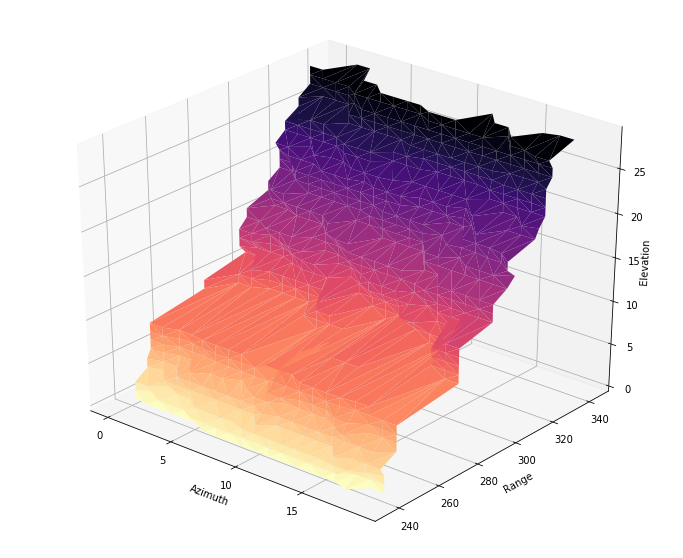

In [101]:
# This import initializes Matplotlib's 3D machinery
from mpl_toolkits.mplot3d import Axes3D

# Set up the 3D axis
f, ax = plt.subplots(1, 1, figsize=(12, 10),
                     subplot_kw=dict(projection='3d'))

with plt.style.context('style/thinner.mplstyle'):
    ax.plot_trisurf(*coords.T, triangles=d.vertices, cmap='magma_r')

    ax.set_xlabel(axis_labels[0])
    ax.set_ylabel(axis_labels[1])
    ax.set_zlabel(axis_labels[2], labelpad=-3)
    ax.set_xticks([0, 5, 10, 15])

# Adjust the camera position to match our diagram above
ax.view_init(azim=-50);